In [ ]:
from utils import *

ModuleNotFoundError: No module named 'src'

In [2]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time
import copy
import os

In [3]:
print(f"Device: {device}")
print(f"NUM_CLASSES: {NUM_CLASSES}")
print(f"IMAGE_SIZE: {IMAGE_SIZE}")
print(f"Train size: {len(train_loader.dataset)}")
print(f"Val size: {len(val_loader.dataset)}")
print(f"BATCH_SIZE: {BATCH_SIZE}")

Device: mps
NUM_CLASSES: 75
IMAGE_SIZE: 64
Train size: 4159
Val size: 1040
BATCH_SIZE: 32


In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    # Normalize reservado para Passo 10
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

In [5]:
train_dataset_cnn = ButterflyDataset(df=train_df, img_dir=img_dir, transform=train_transform)
val_dataset_cnn   = ButterflyDataset(df=val_df,   img_dir=img_dir, transform=val_transform)

train_loader = data.DataLoader(train_dataset_cnn, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = data.DataLoader(val_dataset_cnn,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train size: {len(train_loader.dataset)}")
print(f"Val size:   {len(val_loader.dataset)}")

Train size: 4159
Val size:   1040


In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)

In [7]:
NUM_EPOCHS = 100
PATIENCE   = 7

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS, patience=PATIENCE, device=device, run_name="experiment"):
    counter_early_stopper = 0
    best_weights = None
    best_loss = float("inf")
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, *_ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"Epoch {epoch:3d}/{num_epochs} | Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | Val loss: {vl_loss:.4f} acc: {vl_acc:.4f}")

        if vl_loss < best_loss - 1e-4:
            best_loss = vl_loss
            best_weights = copy.deepcopy(model.state_dict())
            counter_early_stopper = 0
        else:
            counter_early_stopper += 1
            if counter_early_stopper >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    elapsed_min = (time.time() - t0) / 60
    print(f"Training complete in {elapsed_min:.1f} minutes")
    model.load_state_dict(best_weights)
    return model, history, elapsed_min

In [8]:
def compute_metrics(labels, preds, name=""):
    acc = accuracy_score(labels, preds)
    f1_mac = f1_score(labels, preds, average="macro",  zero_division=0)
    f1_wei = f1_score(labels, preds, average="weighted", zero_division=0)

    print(f"{name}->Accuracy : {acc:.4f}")
    print(f"{name}->F1 (macro) : {f1_mac:.4f}")
    print(f"{name}->F1(weighted) : {f1_wei:.4f}")
    return {"accuracy": acc, "f1_macro": f1_mac, "f1_weighted": f1_wei}

def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"],   label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()
    
def plot_confusion_matrix(labels, preds, idx_to_class, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)

    errors_per_class = cm.sum(axis=1) - cm.diagonal()
    top25_idx = np.argsort(errors_per_class)[-25:][::-1]

    cm_top25     = cm[np.ix_(top25_idx, top25_idx)]
    class_names  = [idx_to_class[i] for i in top25_idx]

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm_top25, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.4, cbar_kws={"shrink": 0.7})
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_per_class_accuracy(labels, preds, idx_to_class):
    cm = confusion_matrix(labels, preds)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    sorted_idx   = np.argsort(per_class_acc)
    sorted_acc   = per_class_acc[sorted_idx]
    sorted_names = [idx_to_class[i] for i in sorted_idx]

    fig, ax = plt.subplots(figsize=(10, 18))
    colors = ["tomato" if a < 0.5 else "steelblue" for a in sorted_acc]
    ax.barh(sorted_names, sorted_acc, color=colors, edgecolor="white")
    ax.set_xlabel("Per-class Accuracy")
    ax.set_title("Per-class Accuracy")
    ax.set_xlim(0, 1.0)
    plt.tight_layout()
    plt.show()


In [9]:
idx_to_class = {idx: cls for cls, idx in train_dataset_cnn.class_to_idx.items()}

In [10]:
class CNN_B(nn.Module):
    def __init__(self, input_channels=3, num_classes=NUM_CLASSES):
        super(CNN_B, self).__init__()
        
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        
        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [11]:
model_b = CNN_B()
total_params = sum(p.numel() for p in model_b.parameters())
print(f"CNN_B — Total de parâmetros: {total_params:,}")

CNN_B — Total de parâmetros: 8,447,179


In [12]:
def build_criterion(name):
    if name == "cross_entropy":
        return nn.CrossEntropyLoss()
    elif name == "multi_margin":
        return nn.MultiMarginLoss()
    
def build_optimizer(name, params, lr):
    if name == "adam":
        return optim.Adam(params, lr=lr)
    elif name == "sgd":
        return optim.SGD(params, lr=lr)
    
experiments = [
    ("cnn_b_cel_adam", lambda: CNN_B(), "cross_entropy", "adam", 1e-3),
    ("cnn_b_cel_sgd",  lambda: CNN_B(), "cross_entropy", "sgd",  1e-2),
    ("cnn_b_mml_adam", lambda: CNN_B(), "multi_margin",  "adam", 1e-3),
    ("cnn_b_mml_sgd",  lambda: CNN_B(), "multi_margin",  "sgd",  1e-2),
]


Run: cnn_b_cel_adam
Loss: cross_entropy | Optimizer: adam | LR: 0.001
Epoch   1/100 | Train loss: 4.6761 acc: 0.0325 | Val loss: 3.8022 acc: 0.0750
Epoch   2/100 | Train loss: 3.8966 acc: 0.0536 | Val loss: 3.5274 acc: 0.0942
Epoch   3/100 | Train loss: 3.7424 acc: 0.0565 | Val loss: 3.3726 acc: 0.1250
Epoch   4/100 | Train loss: 3.6615 acc: 0.0683 | Val loss: 3.2463 acc: 0.1462
Epoch   5/100 | Train loss: 3.6200 acc: 0.0726 | Val loss: 3.1087 acc: 0.1760
Epoch   6/100 | Train loss: 3.6158 acc: 0.0767 | Val loss: 3.1858 acc: 0.1538
Epoch   7/100 | Train loss: 3.5786 acc: 0.0765 | Val loss: 3.1309 acc: 0.1673
Epoch   8/100 | Train loss: 3.5349 acc: 0.0926 | Val loss: 3.0444 acc: 0.2087
Epoch   9/100 | Train loss: 3.4867 acc: 0.0921 | Val loss: 2.9604 acc: 0.1942
Epoch  10/100 | Train loss: 3.4542 acc: 0.0885 | Val loss: 3.0629 acc: 0.1817
Epoch  11/100 | Train loss: 3.4500 acc: 0.0894 | Val loss: 2.9385 acc: 0.2019
Epoch  12/100 | Train loss: 3.4144 acc: 0.1015 | Val loss: 2.9064 acc: 

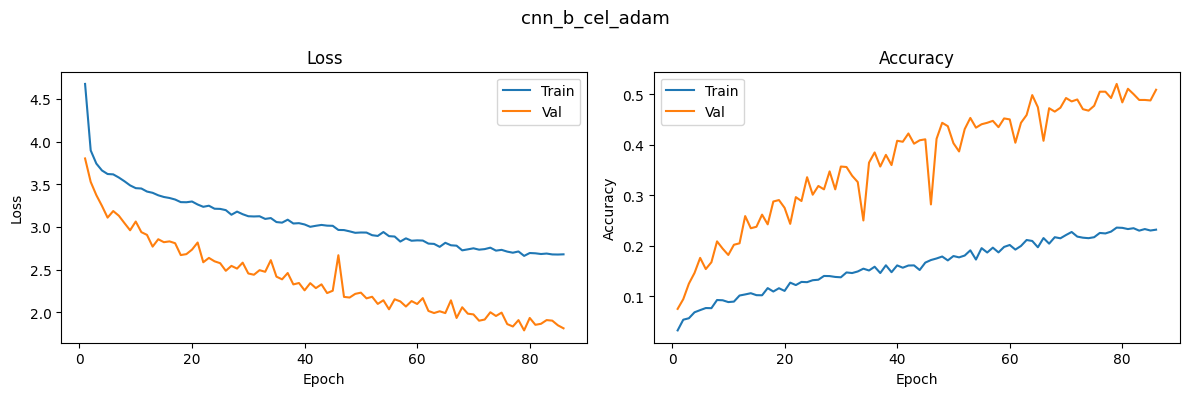


Run: cnn_b_cel_sgd
Loss: cross_entropy | Optimizer: sgd | LR: 0.01
Epoch   1/100 | Train loss: 4.1380 acc: 0.0445 | Val loss: 3.6633 acc: 0.1471
Epoch   2/100 | Train loss: 3.6507 acc: 0.0962 | Val loss: 3.2184 acc: 0.2087
Epoch   3/100 | Train loss: 3.2933 acc: 0.1524 | Val loss: 2.8623 acc: 0.2952
Epoch   4/100 | Train loss: 3.0604 acc: 0.1981 | Val loss: 2.7225 acc: 0.3087
Epoch   5/100 | Train loss: 2.8941 acc: 0.2356 | Val loss: 2.4271 acc: 0.3663
Epoch   6/100 | Train loss: 2.7176 acc: 0.2707 | Val loss: 2.2207 acc: 0.4365
Epoch   7/100 | Train loss: 2.6101 acc: 0.2957 | Val loss: 2.0957 acc: 0.4471
Epoch   8/100 | Train loss: 2.5367 acc: 0.3147 | Val loss: 2.0022 acc: 0.4625
Epoch   9/100 | Train loss: 2.4251 acc: 0.3388 | Val loss: 2.1270 acc: 0.4260
Epoch  10/100 | Train loss: 2.3548 acc: 0.3590 | Val loss: 1.9780 acc: 0.4798
Epoch  11/100 | Train loss: 2.2625 acc: 0.3830 | Val loss: 1.9197 acc: 0.4673
Epoch  12/100 | Train loss: 2.2231 acc: 0.3809 | Val loss: 1.7136 acc: 0.5

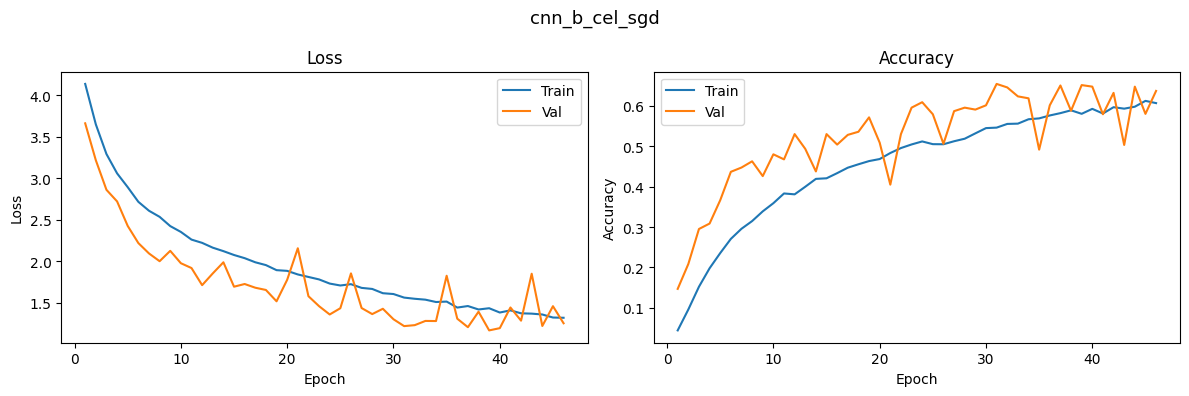


Run: cnn_b_mml_adam
Loss: multi_margin | Optimizer: adam | LR: 0.001
Epoch   1/100 | Train loss: 1.1584 acc: 0.0394 | Val loss: 0.5158 acc: 0.0731
Epoch   2/100 | Train loss: 0.5820 acc: 0.0613 | Val loss: 0.3557 acc: 0.1125
Epoch   3/100 | Train loss: 0.5107 acc: 0.0680 | Val loss: 0.3276 acc: 0.1288
Epoch   4/100 | Train loss: 0.4720 acc: 0.0813 | Val loss: 0.3103 acc: 0.1462
Epoch   5/100 | Train loss: 0.4348 acc: 0.0861 | Val loss: 0.2755 acc: 0.1683
Epoch   6/100 | Train loss: 0.4168 acc: 0.0947 | Val loss: 0.2499 acc: 0.1798
Epoch   7/100 | Train loss: 0.3901 acc: 0.1056 | Val loss: 0.2190 acc: 0.2327
Epoch   8/100 | Train loss: 0.3680 acc: 0.1159 | Val loss: 0.2384 acc: 0.1981
Epoch   9/100 | Train loss: 0.3555 acc: 0.1157 | Val loss: 0.2359 acc: 0.2000
Epoch  10/100 | Train loss: 0.3604 acc: 0.1159 | Val loss: 0.2576 acc: 0.2106
Epoch  11/100 | Train loss: 0.3237 acc: 0.1310 | Val loss: 0.1882 acc: 0.2702
Epoch  12/100 | Train loss: 0.3223 acc: 0.1375 | Val loss: 0.1739 acc: 0

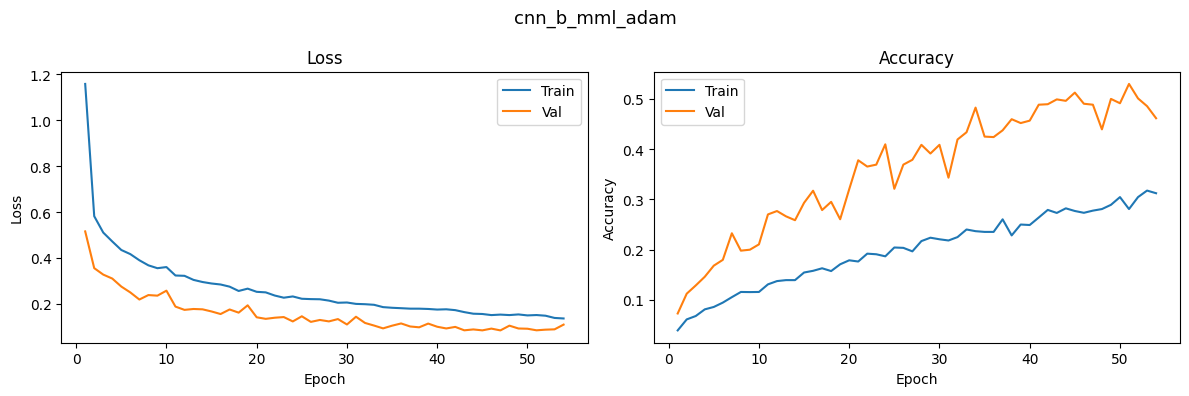


Run: cnn_b_mml_sgd
Loss: multi_margin | Optimizer: sgd | LR: 0.01
Epoch   1/100 | Train loss: 0.7802 acc: 0.0435 | Val loss: 0.4706 acc: 0.1356
Epoch   2/100 | Train loss: 0.4826 acc: 0.0935 | Val loss: 0.3013 acc: 0.2269
Epoch   3/100 | Train loss: 0.3801 acc: 0.1185 | Val loss: 0.2388 acc: 0.2635
Epoch   4/100 | Train loss: 0.3197 acc: 0.1527 | Val loss: 0.2064 acc: 0.3115
Epoch   5/100 | Train loss: 0.2887 acc: 0.1823 | Val loss: 0.1846 acc: 0.3375
Epoch   6/100 | Train loss: 0.2600 acc: 0.1952 | Val loss: 0.1665 acc: 0.3413
Epoch   7/100 | Train loss: 0.2431 acc: 0.2152 | Val loss: 0.1558 acc: 0.3856
Epoch   8/100 | Train loss: 0.2282 acc: 0.2361 | Val loss: 0.1527 acc: 0.3971
Epoch   9/100 | Train loss: 0.2194 acc: 0.2325 | Val loss: 0.1397 acc: 0.4067
Epoch  10/100 | Train loss: 0.2094 acc: 0.2477 | Val loss: 0.1391 acc: 0.4115
Epoch  11/100 | Train loss: 0.1965 acc: 0.2642 | Val loss: 0.1279 acc: 0.4404
Epoch  12/100 | Train loss: 0.1873 acc: 0.2806 | Val loss: 0.1293 acc: 0.42

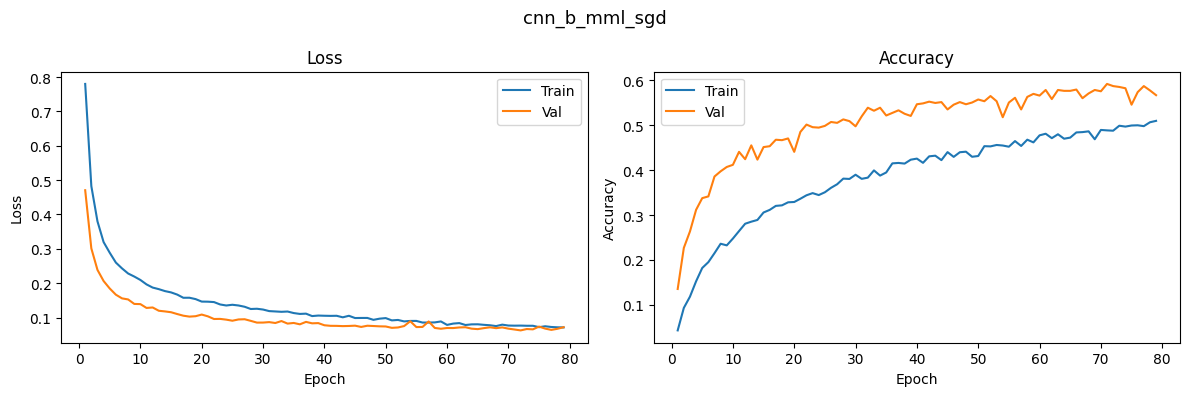

In [13]:
results_summary = []
trained_models  = {}
all_histories   = {}
all_times       = {}

for run_name, model_fn, loss_name, optim_name, lr in experiments:
    print(f"\n{'='*60}")
    print(f"Run: {run_name}")
    print(f"Loss: {loss_name} | Optimizer: {optim_name} | LR: {lr}")
    print(f"{'='*60}")

    run_device = torch.device("cpu") if loss_name == "multi_margin" else device

    model     = model_fn().to(run_device)
    criterion = build_criterion(loss_name)
    optimizer = build_optimizer(optim_name, model.parameters(), lr)

    model, history, elapsed = train_model(
        model, train_loader, val_loader,
        criterion, optimizer,
        device=run_device,
        run_name=run_name
    )

    _, _, labels, preds = evaluate(model, val_loader, criterion, run_device)
    metrics = compute_metrics(labels, preds, name=run_name)

    results_summary.append({
        "run":       run_name,
        "loss":      loss_name,
        "optimizer": optim_name,
        "lr":        lr,
        "time_min":  round(elapsed, 2),
        **metrics
    })

    trained_models[run_name] = model
    all_histories[run_name]  = history
    all_times[run_name]      = elapsed

    plot_history(history, title=run_name)

In [14]:
df_results = pd.DataFrame(results_summary).sort_values("f1_macro", ascending=False).reset_index(drop=True)
pd.set_option("display.float_format", "{:.4f}".format)
print(df_results.to_string(index=False))

           run          loss optimizer     lr  time_min  accuracy  f1_macro  f1_weighted
 cnn_b_cel_sgd cross_entropy       sgd 0.0100    7.6500    0.6510    0.6343       0.6349
 cnn_b_mml_sgd  multi_margin       sgd 0.0100   22.0900    0.5865    0.5778       0.5779
cnn_b_cel_adam cross_entropy      adam 0.0010   13.9400    0.5202    0.4745       0.4782
cnn_b_mml_adam  multi_margin      adam 0.0010   16.0700    0.4885    0.4545       0.4576


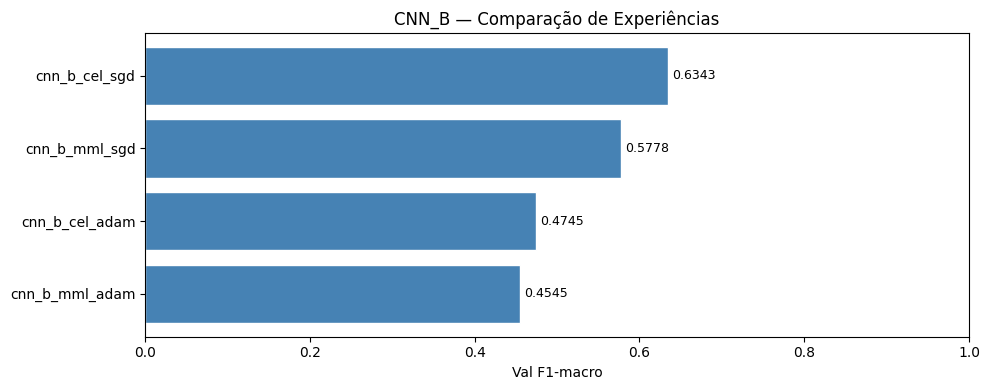

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_results["run"][::-1], df_results["f1_macro"][::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Val F1-macro")
ax.set_title("CNN_B — Comparação de Experiências")
ax.set_xlim(0, 1.0)
for bar, val in zip(bars, df_results["f1_macro"][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [16]:
best_run   = df_results.iloc[0]["run"]
best_model = trained_models[best_run]
print(f"Melhor modelo: {best_run}\n")

_, _, labels, preds = evaluate(best_model, val_loader, build_criterion(df_results.iloc[0]["loss"]), device)

print(classification_report(labels, preds, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)], zero_division=0))

Melhor modelo: cnn_b_cel_sgd

                           precision    recall  f1-score   support

                   ADONIS       1.00      0.79      0.88        14
AFRICAN GIANT SWALLOWTAIL       0.73      0.67      0.70        12
           AMERICAN SNOOT       0.31      0.67      0.42        12
                    AN 88       0.87      0.93      0.90        14
                  APPOLLO       0.77      0.71      0.74        14
                    ATALA       0.67      0.75      0.71        16
 BANDED ORANGE HELICONIAN       0.75      0.80      0.77        15
           BANDED PEACOCK       0.75      0.92      0.83        13
            BECKERS WHITE       0.33      0.08      0.12        13
         BLACK HAIRSTREAK       1.00      0.79      0.88        14
              BLUE MORPHO       0.60      0.25      0.35        12
        BLUE SPOTTED CROW       0.40      0.29      0.33        14
           BROWN SIPROETA       1.00      0.62      0.77        16
            CABBAGE WHITE      

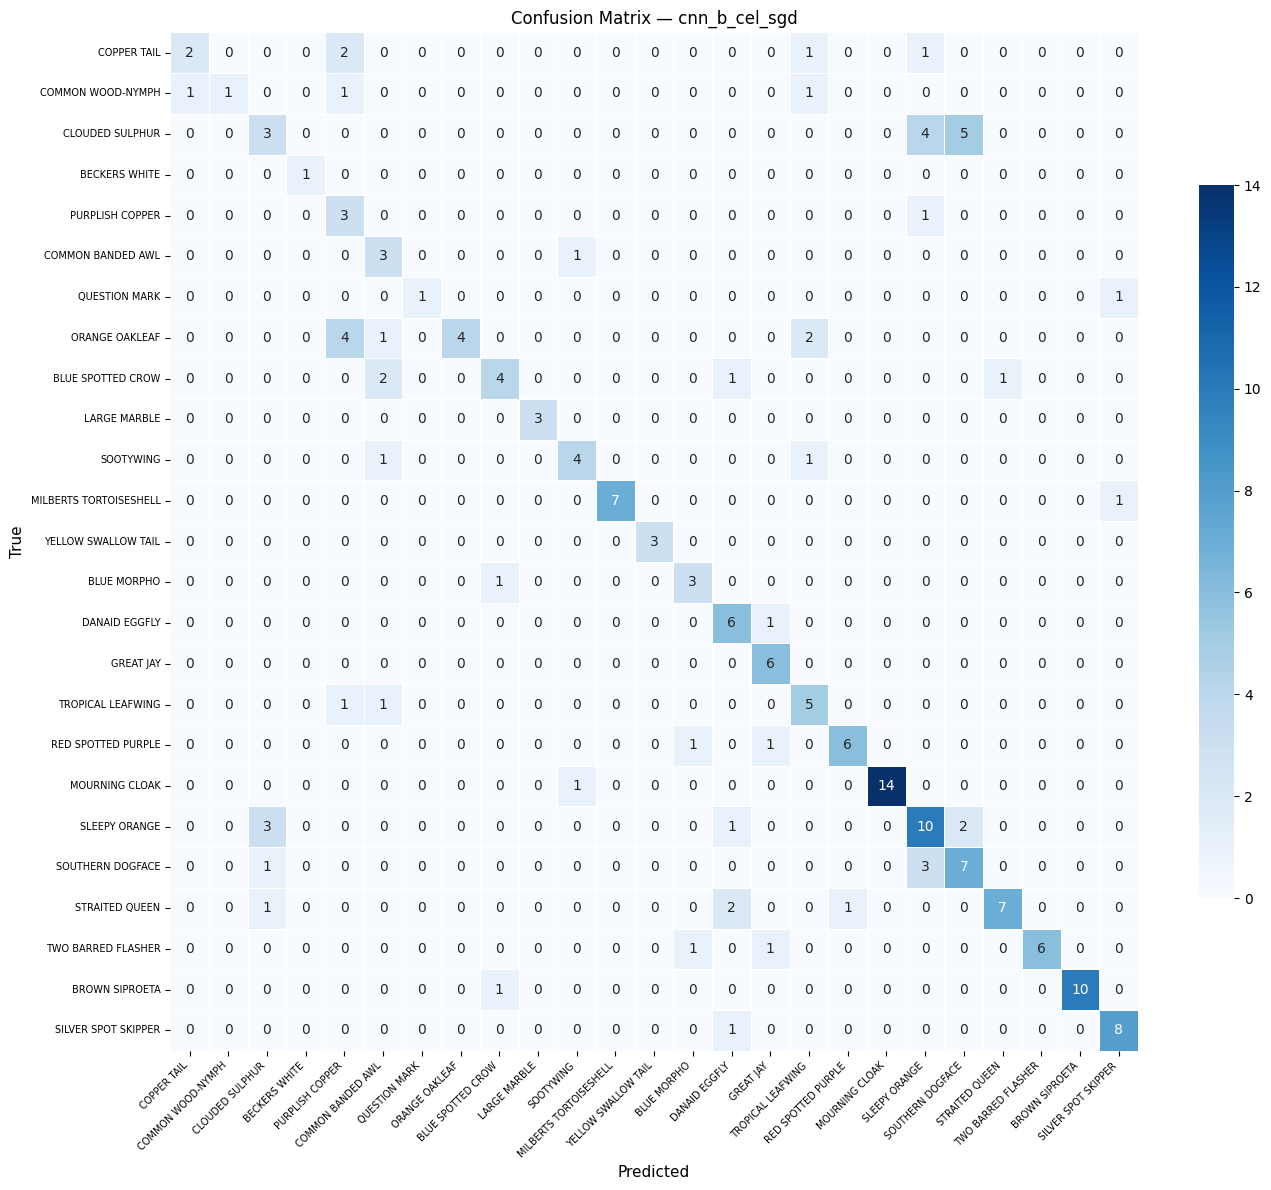

In [17]:
plot_confusion_matrix(labels, preds, idx_to_class, title=f"Confusion Matrix — {best_run}")

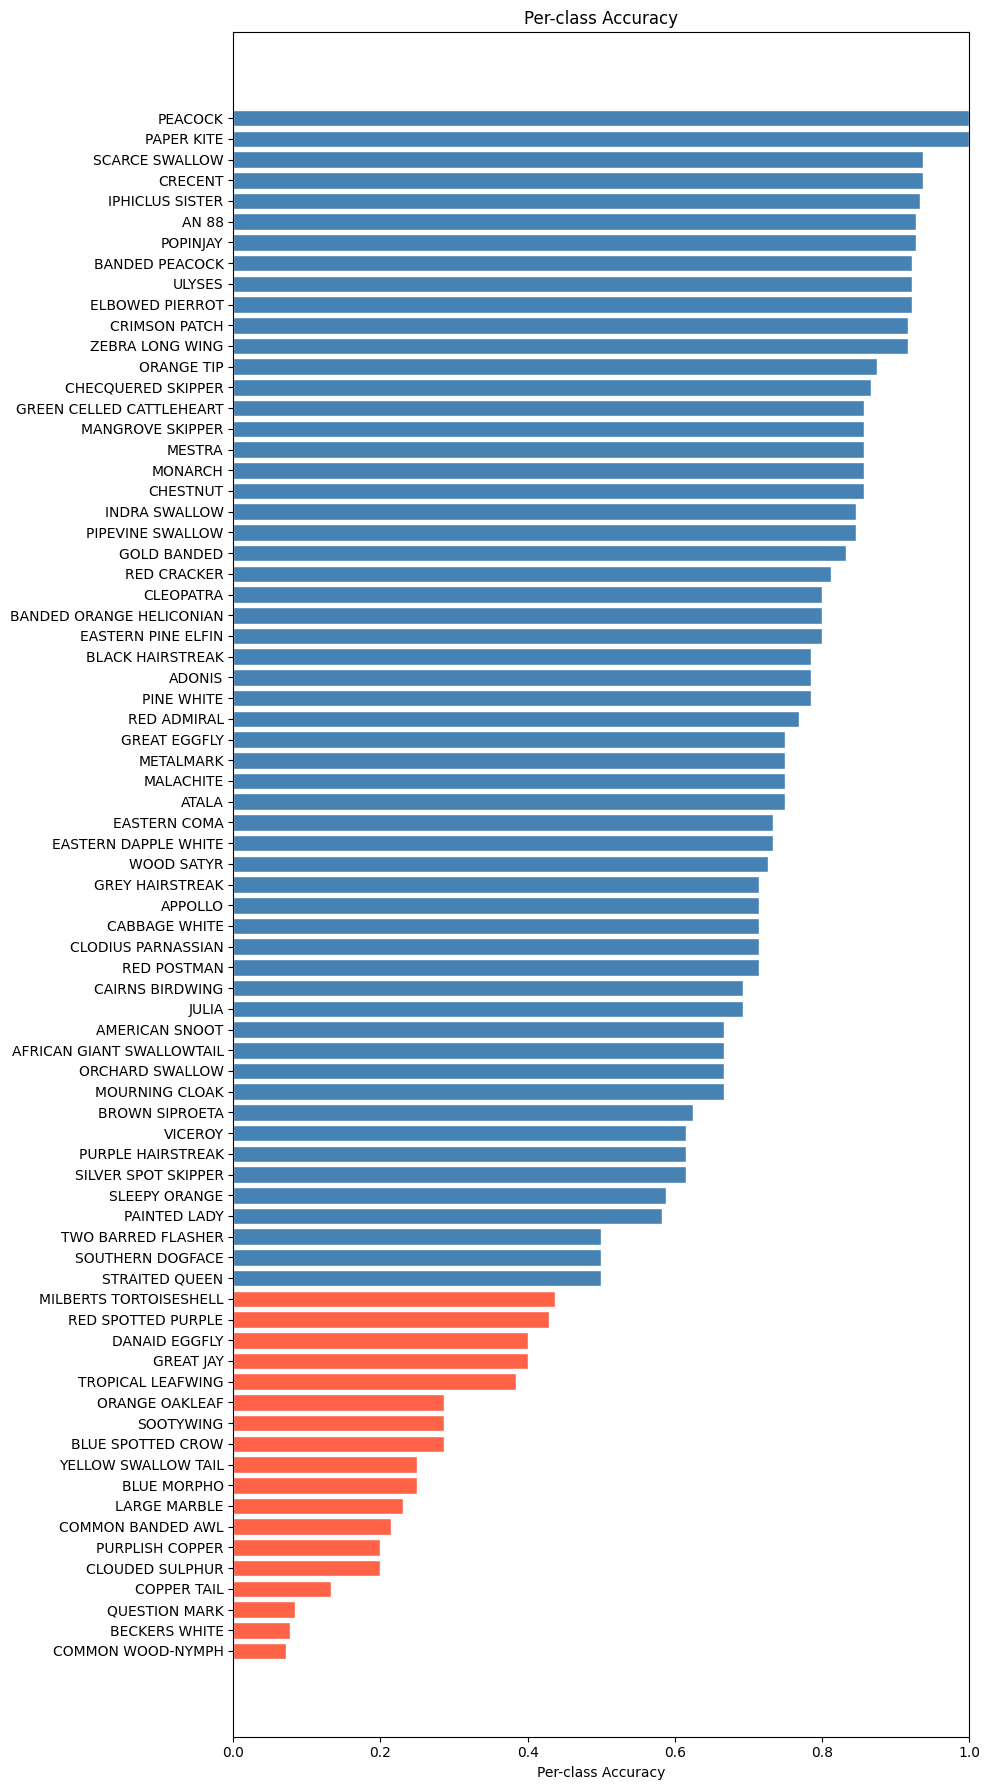

In [18]:
plot_per_class_accuracy(labels, preds, idx_to_class)

## Normalização daqui para a frente

In [19]:
train_transform_norm = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(RGB_MEAN, RGB_STD),
])

val_transform_norm = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(RGB_MEAN, RGB_STD),
])

In [20]:
train_dataset_norm = ButterflyDataset(df=train_df, img_dir=img_dir, transform=train_transform_norm)
val_dataset_norm   = ButterflyDataset(df=val_df,   img_dir=img_dir, transform=val_transform_norm)

train_loader_norm = data.DataLoader(train_dataset_norm, batch_size=BATCH_SIZE, shuffle=True)
val_loader_norm   = data.DataLoader(val_dataset_norm,   batch_size=BATCH_SIZE, shuffle=False)

Epoch   1/100 | Train loss: 4.0967 acc: 0.0599 | Val loss: 3.5651 acc: 0.1279
Epoch   2/100 | Train loss: 3.5145 acc: 0.1296 | Val loss: 3.0079 acc: 0.2442
Epoch   3/100 | Train loss: 3.1404 acc: 0.1904 | Val loss: 2.6604 acc: 0.2952
Epoch   4/100 | Train loss: 2.9480 acc: 0.2198 | Val loss: 2.4695 acc: 0.3654
Epoch   5/100 | Train loss: 2.7661 acc: 0.2652 | Val loss: 2.2578 acc: 0.4010
Epoch   6/100 | Train loss: 2.6323 acc: 0.3042 | Val loss: 2.1356 acc: 0.4365
Epoch   7/100 | Train loss: 2.5163 acc: 0.3229 | Val loss: 2.0261 acc: 0.4683
Epoch   8/100 | Train loss: 2.4155 acc: 0.3446 | Val loss: 1.9721 acc: 0.4712
Epoch   9/100 | Train loss: 2.3662 acc: 0.3640 | Val loss: 1.9058 acc: 0.4673
Epoch  10/100 | Train loss: 2.2765 acc: 0.3797 | Val loss: 1.8866 acc: 0.4817
Epoch  11/100 | Train loss: 2.2091 acc: 0.3852 | Val loss: 1.7388 acc: 0.5010
Epoch  12/100 | Train loss: 2.1085 acc: 0.4186 | Val loss: 1.7002 acc: 0.5231
Epoch  13/100 | Train loss: 2.0878 acc: 0.4174 | Val loss: 1.676

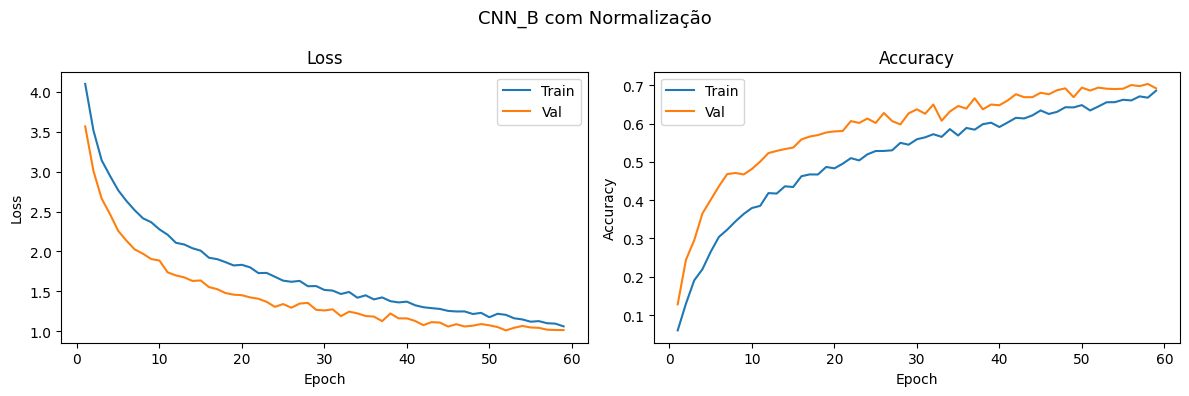

In [21]:
best_loss_name  = df_results.iloc[0]["loss"]
best_optim_name = df_results.iloc[0]["optimizer"]
best_lr         = df_results.iloc[0]["lr"]

model_norm    = CNN_B().to(device)
criterion_norm = build_criterion(best_loss_name)
optimizer_norm = build_optimizer(best_optim_name, model_norm.parameters(), best_lr)

model_norm, history_norm, elapsed_norm = train_model(
    model_norm, train_loader_norm, val_loader_norm,
    criterion_norm, optimizer_norm,
    run_name="cnn_b_norm"
)

_, _, labels_norm, preds_norm = evaluate(model_norm, val_loader_norm, criterion_norm, device)
metrics_norm = compute_metrics(labels_norm, preds_norm, name="cnn_b_norm")

plot_history(history_norm, title="CNN_B com Normalização")

In [22]:
print("Sem normalização:")
compute_metrics(labels, preds, name=best_run)

print("\nCom normalização:")
compute_metrics(labels_norm, preds_norm, name="cnn_b_norm")

Sem normalização:
cnn_b_cel_sgd->Accuracy : 0.6510
cnn_b_cel_sgd->F1 (macro) : 0.6343
cnn_b_cel_sgd->F1(weighted) : 0.6349

Com normalização:
cnn_b_norm->Accuracy : 0.6942
cnn_b_norm->F1 (macro) : 0.6897
cnn_b_norm->F1(weighted) : 0.6894


{'accuracy': 0.6942307692307692,
 'f1_macro': 0.6896894963894016,
 'f1_weighted': 0.6893609119918725}